# FRED Data Acquisition
Pulling risk-free rate (3-month Treasury yield) and CPI from FRED for use in Sharpe ratio and macro context calculations.

In [9]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from dotenv import load_dotenv
from fredapi import Fred

## Setup paths and API connection

In [3]:
RAW_DATA_PATH = Path('../data/raw')
PROCESSED_DATA_PATH = Path('../data/processed')

RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

In [4]:
load_dotenv()  # reads FRED_API_KEY from .env
FRED_API_KEY = os.getenv('FRED_API_KEY')

assert FRED_API_KEY is not None, "FRED_API_KEY not found - check your .env file"

fred = Fred(api_key=FRED_API_KEY)
print("Connected to FRED API")

Connected to FRED API


## Pull risk-free rate (3-month Treasury yield)
Series ID: `DGS3MO` — the standard proxy for the risk-free rate in Sharpe ratio calculations.

In [5]:
rf_raw = fred.get_series('DGS3MO')
rf_raw = rf_raw.to_frame(name='risk_free_rate_pct')
rf_raw.index.name = 'date'

print(f"Pulled {len(rf_raw)} rows")
print(f"Date range: {rf_raw.index.min()} to {rf_raw.index.max()}")
rf_raw.head()

Pulled 11696 rows
Date range: 1981-09-01 00:00:00 to 2026-06-30 00:00:00


,risk_free_rate_pct
date,
1981-09-01,17.01
1981-09-02,16.65
1981-09-03,16.96
1981-09-04,16.64
1981-09-07,NaN


## Pull CPI (optional macro context)
Series ID: `CPIAUCSL` — Consumer Price Index, monthly. Useful for inflation-adjusted context during the backtest period.

In [6]:
cpi_raw = fred.get_series('CPIAUCSL')
cpi_raw = cpi_raw.to_frame(name='cpi_index')
cpi_raw.index.name = 'date'

print(f"Pulled {len(cpi_raw)} rows")
cpi_raw.head()

Pulled 953 rows


,cpi_index
date,
1947-01-01,21.48
1947-02-01,21.62
1947-03-01,22.00
1947-04-01,22.00
1947-05-01,21.95


## Quick sanity checks

Risk-free rate missing values: 490
CPI missing values: 1


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': '3-Month Treasury Yield (Raw)'}, xlabel='date'>

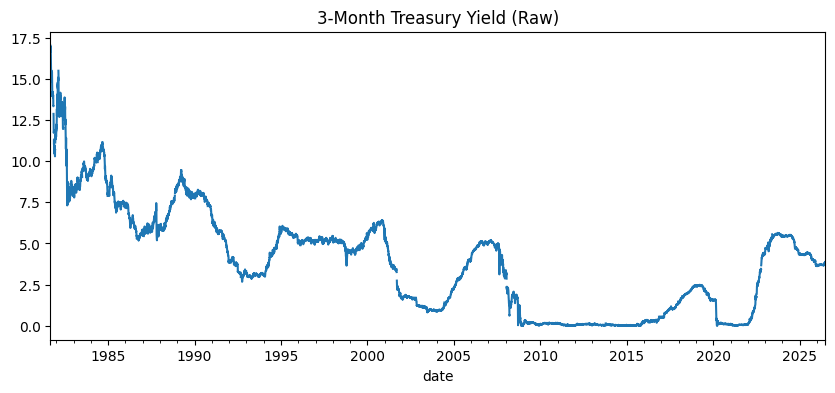

In [13]:
print("Risk-free rate missing values:", rf_raw['risk_free_rate_pct'].isna().sum())
print("CPI missing values:", cpi_raw['cpi_index'].isna().sum())

rf_raw['risk_free_rate_pct'].plot(title='3-Month Treasury Yield (Raw)', figsize=(10,4))

## Save raw data

In [14]:
rf_raw.to_csv(RAW_DATA_PATH / 'fred_risk_free_rate_raw.csv')
cpi_raw.to_csv(RAW_DATA_PATH / 'fred_cpi_raw.csv')

print("Saved raw FRED data to", RAW_DATA_PATH)

Saved raw FRED data to ../data/raw
